In [1]:
!pip install -q tensorflow pandas scikit-learn

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.utils import to_categorical

In [3]:
DATA_FILE_PATH = '../data/Preprocessed/cicids2017_preprocessed.csv'

In [4]:
try:
    print(f"Loading data from {DATA_FILE_PATH}...")
    df = pd.read_csv(DATA_FILE_PATH)
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"Error: The file {DATA_FILE_PATH} was not found. Please ensure your preprocessed CSV is in the correct directory.")
    exit()

Loading data from ../data/Preprocessed/cicids2017_preprocessed.csv...
Data loaded successfully.


In [5]:
# Separate features (X) and labels (y)
# 'Label' is typically the column that indicates whether a traffic flow is 'Normal' or an 'Attack'.
X = df.drop('label', axis=1)
y = df['label']

In [6]:
# Check the number of unique classes to define the output layer
num_classes = len(y.unique())
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {num_classes}")

Number of features: 78
Number of classes: 15


# --- Train-Test-Validation Split ---
# We split the data into three sets:
# - Training set (70%): Used to train the model.
# - Validation set (15%): Used during training to monitor performance and prevent overfitting.
# - Test set (15%): A completely unseen set of data used for final model evaluation.

In [7]:
# First, split the data into a training set and a temporary set (combining validation and test)
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [8]:
# Now, split the temporary set into validation and test sets
# This creates a 70/15/15 split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.5, random_state=42, stratify=y_train_temp
)

In [9]:
# Reshape data for CNN-LSTM input
# The model expects a 3D input of shape (samples, timesteps, features).
# For tabular data, we can set timesteps to 1.
# This is a common practice for converting tabular data for a sequence model.
n_features = X_train.shape[1]
X_train = np.asarray(X_train).reshape((X_train.shape[0], 1, n_features))
X_val = np.asarray(X_val).reshape((X_val.shape[0], 1, n_features))
X_test = np.asarray(X_test).reshape((X_test.shape[0], 1, n_features))

In [10]:
print("\n--- Data Split and Reshaping Summary ---")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}, y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")


--- Data Split and Reshaping Summary ---
X_train shape: (990760, 1, 78), y_train shape: (990760,)
X_val shape:   (990760, 1, 78), y_val shape:   (990760,)
X_test shape:  (849223, 1, 78), y_test shape:  (849223,)


# Convert labels to one-hot encoding for the model if needed,
# but sparse_categorical_crossentropy is more efficient and handles integer labels.
# For simplicity, we'll keep integer labels and use `sparse_categorical_crossentropy`.

# --- Build the CNN-LSTM Model ---
# This is a lightweight model architecture designed for efficiency.
# - Conv1D: Used to extract relevant features from the input data.
# - LSTM: Captures temporal dependencies or patterns in the extracted features.
# - Dense: The final layers that make the classification prediction.

In [11]:
model = Sequential([
    # A single 1D Convolutional layer to capture local features.
    Conv1D(filters=64, kernel_size=1, activation='relu', input_shape=(1, n_features)),
    
    # An LSTM layer to capture sequential patterns.
    # The return_sequences=False argument ensures the LSTM outputs a single vector,
    # which is what our final Dense layers expect.
    LSTM(units=50, return_sequences=False),
    
    # Dropout layer to prevent overfitting by randomly dropping neurons during training.
    Dropout(0.2),
    
    # A Dense hidden layer with ReLU activation.
    Dense(units=100, activation='relu'),
    
    # Output layer with 'softmax' activation for multi-class classification.
    # The number of units must match the number of unique classes.
    Dense(units=num_classes, activation='softmax')
])

c:\Users\vicky\miniconda3\envs\thesis\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# Compile the model
# - 'adam' is a popular and efficient optimizer.
# - 'sparse_categorical_crossentropy' is the best loss function for integer-encoded labels.
# - We'll monitor 'accuracy' during training.
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1, 64)          │         5,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50)             │        23,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │         5,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,515 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,671 (135.43 KB)

 Trainable params: 34,671 (135.43 KB)

 Non-trainable params: 0 (0.00 B)

# --- Train the Model ---
# We train the model using the training data and validate it with the validation set.
# The 'epochs' parameter defines the number of passes through the entire training dataset.
# The 'batch_size' determines how many samples are passed to the model at a time.
# The 'callbacks' argument can be used to add functionality like early stopping.

In [14]:
# Define an EarlyStopping callback to stop training when the validation loss stops improving.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [15]:
print("\n--- Starting Model Training ---")
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)
print("Model training finished.")


--- Starting Model Training ---
Epoch 1/50
3871/3871 ━━━━━━━━━━━━━━━━━━━━ 79s 18ms/step - accuracy: 0.9607 - loss: 0.1239 - val_accuracy: 0.9754 - val_loss: 0.0593
Epoch 2/50
3871/3871 ━━━━━━━━━━━━━━━━━━━━ 95s 24ms/step - accuracy: 0.9764 - loss: 0.0562 - val_accuracy: 0.9813 - val_loss: 0.0500
Epoch 3/50
3871/3871 ━━━━━━━━━━━━━━━━━━━━ 62s 16ms/step - accuracy: 0.9815 - loss: 0.0455 - val_accuracy: 0.9845 - val_loss: 0.0378
Epoch 4/50
3871/3871 ━━━━━━━━━━━━━━━━━━━━ 62s 16ms/step - accuracy: 0.9868 - loss: 0.0349 - val_accuracy: 0.9889 - val_loss: 0.0265
Epoch 5/50
3871/3871 ━━━━━━━━━━━━━━━━━━━━ 62s 16ms/step - accuracy: 0.9917 - loss: 0.0246 - val_accuracy: 0.9921 - val_loss: 0.0218
Epoch 6/50
3871/3871 ━━━━━━━━━━━━━━━━━━━━ 65s 17ms/step - accuracy: 0.9928 - loss: 0.0211 - val_accuracy: 0.9945 - val_loss: 0.0186
Epoch 7/50
3871/3871 ━━━━━━━━━━━━━━━━━━━━ 63s 16ms/step - accuracy: 0.9934 - loss: 0.0194 - val_accuracy: 0.9924 - val_loss: 0.0183
Epoch 8/50
3871/3871 ━━━━━━━━━━━━━━━━━━━━ 6

# --- Test and Validate the Model ---

In [16]:
# Evaluate the model on the unseen test data to get its final performance metrics.
print("\n--- Evaluating Model on Test Data ---")
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


--- Evaluating Model on Test Data ---
Test Loss: 0.0111
Test Accuracy: 0.9966


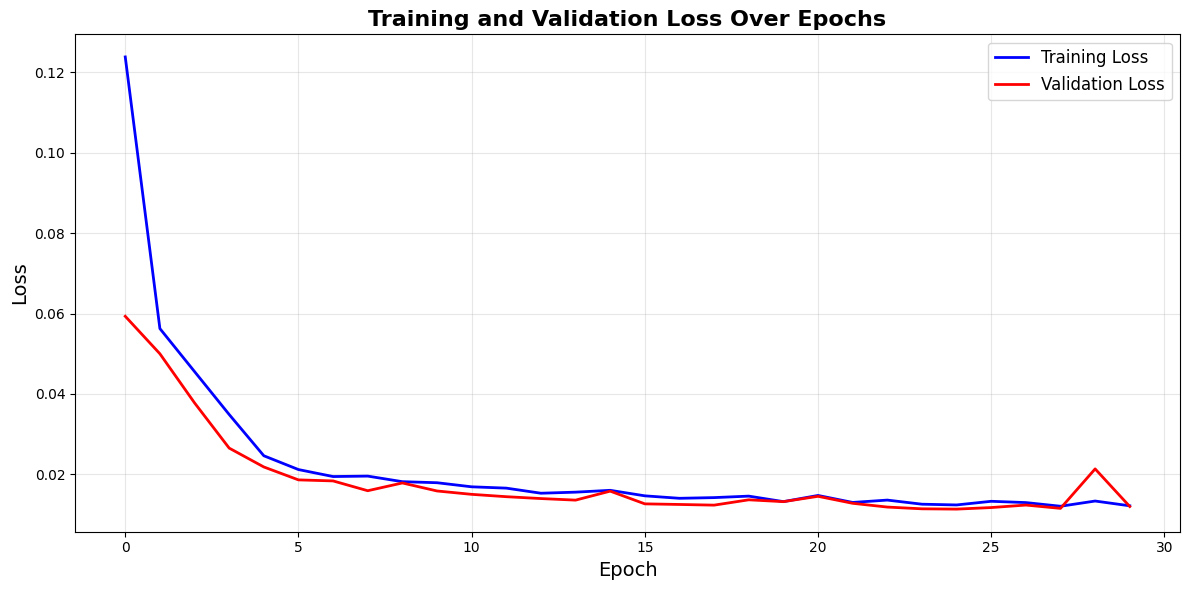

Final Training Loss: 0.0121
Final Validation Loss: 0.0120
Best Validation Loss: 0.0113 (Epoch 25)

Model appears to be generalizing well


In [19]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', linewidth=2)
plt.title('Training and Validation Loss Over Epochs', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print final loss values
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"Best Validation Loss: {min(history.history['val_loss']):.4f} (Epoch {history.history['val_loss'].index(min(history.history['val_loss'])) + 1})")

# Check for overfitting
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

if final_val_loss > final_train_loss * 1.1:
    print("\nPotential overfitting detected: Validation loss is significantly higher than training loss")
else:
    print("\nModel appears to be generalizing well")
